In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
import time

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from  sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, silhouette_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Load data and set up the experiment

Full MNIST training CSV: 60,000 images, 784 pixels each. Pixels are scaled
to [0, 1]. Since this file has no separate test set, a stratified 80/20
split creates one (48,000 train / 12,000 test). Every reducer below is
fit on the **training split only**.

In [36]:
# As the downloaded data was already split into train and test sets
df_train = pd.read_csv("../data/mnist_train.csv")
df_test = pd.read_csv("../data/mnist_test.csv")

df = pd.concat([df_train, df_test], ignore_index=True)

y = df["label"].values
X = df.drop(columns="label").values.astype(np.float32) / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

total_digit = len(np.unique(y))
print("       ---- Data info ---- ")
print(f"Shape -->   Train Data: {X_train.shape} | Test Data: {X_test.shape}")
print(f"Pixels -->  28 X 28 ")
print(f"Classes : {np.unique(y)} | Class count : {total_digit}")
print(f"Constant (zero-variance) pixels : {((X.std(axis=0) == 0).sum())} of {X.shape[1]}")


       ---- Data info ---- 
Shape -->   Train Data: (56000, 784) | Test Data: (14000, 784)
Pixels -->  28 X 28 
Classes : [0 1 2 3 4 5 6 7 8 9] | Class count : 10
Constant (zero-variance) pixels : 65 of 784


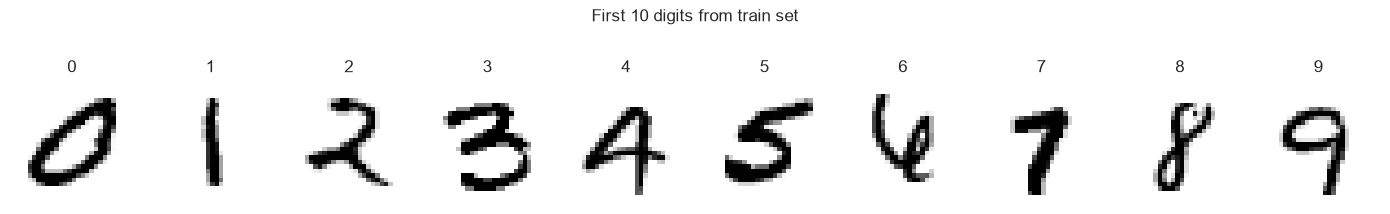

In [38]:
fig , axes = plt.subplots(1,10, figsize=(14,1.9))

for digit in range(total_digit):
    axes[digit].imshow(X_train[np.where(y_train == digit)[0][0]].reshape(28, 28), cmap='gray_r')
    axes[digit].set_title(str(digit))
    axes[digit].axis('off')
    
plt.suptitle("First 10 digits from train set", y=1.12)
plt.tight_layout()
plt.show()

**Observation — note the 67 constant pixels.** These are border pixels
that are zero in every single image. They carry no information, and for
LDA they are not just useless but *structurally problematic* — Section 3
shows exactly what they break.

In [47]:
from sklearn.neighbors import KNeighborsClassifier

def knn_benchmark(X_train, X_test, y_train, y_test, n_neighbors=5, timing_repeats=7):
    
    # KNN Classifier
    knn_clf = KNeighborsClassifier(n_neighbors=n_neighbors, algorithm='brute', n_jobs=-1)
    
    # Train the model on the training data
    start_time = time.perf_counter()
    knn_clf.fit(X_train, y_train)
    train_time = time.perf_counter() - start_time
    
    
    # Predict on the test data
    t0 = time.perf_counter()
    y_pred = knn_clf.predict(X_test)
    pred_time = time.perf_counter() - t0
    
    accuracy = accuracy_score(y_test, y_pred)
    
    return {"accuracy" :accuracy, "train_time":train_time, "predict_time":pred_time}


In [57]:
# Model training and evaluation
baseline_model = knn_benchmark(X_train, X_test, y_train, y_test)

print(f"------ Baseline Model -----")
print(f" Accuracy         : {baseline_model['accuracy']:3f}")
print(f" Training Time    : {baseline_model['train_time']*1000:.3f} ms")
print(f" Prediction speed : {baseline_model['predict_time']*1000:.3f} ms")

------ Baseline Model -----
 Accuracy         : 0.969643
 Training Time    : 11.859 ms
 Prediction speed : 2721.454 ms


## 2. The structural fact that defines LDA: the (classes - 1) ceiling

PCA can return anywhere from 1 up to min(samples, features) components.
LDA cannot. Its between-class scatter matrix is built from the 10 class
means, and 10 means around one global mean span at most a 9-dimensional
subspace — so the matrix has rank at most 9, and **LDA can produce at most
9 meaningful components here, no matter how many pixels there are.**

This isn't a tunable parameter. Try asking for more:

In [61]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

try : 
    LDA(n_components = total_digit).fit(X_train[:5000], y_train[:5000])
except ValueError as e:
    print("ValueError : ",e)
    print("LDA can produce at most 9 meaningful components here, no matter how many pixels there are.")

ValueError :  n_components cannot be larger than min(n_features, n_classes - 1).
LDA can produce at most 9 meaningful components here, no matter how many pixels there are.


**Consequence worth internalizing:** for a **2-class** problem LDA yields
exactly **1** component, regardless of whether the data has 5 features or
5,000. Section 11 uses this when deciding where LDA fits.

In [62]:
binary_mask = (y_train == 0) | (y_train == 1)
lda_binary = LDA().fit(X_train[binary_mask], y_train[binary_mask])

print("0 vs 1 problem ---> LDA Output Shape : ",
    lda_binary.transform(X_train[binary_mask][:5]).shape)

0 vs 1 problem ---> LDA Output Shape :  (5, 1)


## 3. Fitting LDA — and what the singular scatter matrix does to it

LDA's core computation inverts (or solves against) the **within-class
scatter matrix**. With 67 pixels that never vary, that matrix is
**singular** — it has zero-variance directions and cannot be inverted
directly. sklearn offers solvers that handle this differently:

In [73]:
# 1) 'Eigen' Solver, no regularization: need the matrix to be invertible
try:
    LDA(solver='eigen').fit(X_train, y_train)
    print("Eigen (no shrinkage): Fit Succeeded ")
except Exception as e:
    print(f"Eigen (no shrinkage) : FAILED --> {type(e).__name__}:{str(e)[:110]}...")


# 2) 'SVD' Solver : Never forms the covariance matrix, so singularity is harmless
t0 = time.perf_counter()
lda_svd = LDA(solver = "svd").fit(X_train, y_train)
print(f"SVD (no shrinkage): Fit Succeeded in {time.perf_counter() - t0:.2f} seconds")

# 3) 'Eigen' + shrinkage : regularizes the covariance estimate so it is invertible 
t0 = time.perf_counter()
lad_shrink = LDA(solver = "eigen", shrinkage="auto").fit(X_train, y_train)
print(f"Eigen + Shrinkage='auto': Fit Succeeded in {time.perf_counter() - t0:.2f} seconds")

Eigen (no shrinkage) : FAILED --> LinAlgError:The leading minor of order 1 of B is not positive definite. The factorization of B could not be completed and ...
SVD (no shrinkage): Fit Succeeded in 0.92 seconds
Eigen + Shrinkage='auto': Fit Succeeded in 0.68 seconds


**Observation:** the unregularized `eigen` solver fails outright on raw
MNIST — a direct consequence of the constant pixels making the scatter
matrix singular. The default `svd` solver sidesteps the problem entirely,
and shrinkage fixes it by blending the estimated covariance toward a
well-conditioned target. **Practical rule:** on real, high-dimensional,
messy data, never assume the within-class scatter is invertible. Use `svd`
(the default) or add shrinkage.

Solver capabilities worth knowing (they differ more than the names suggest):
`svd` supports `transform()` but **not** shrinkage; `lsqr` supports shrinkage
but **not** `transform()` (classification only); `eigen` supports **both**
`transform()` and shrinkage. So when you need a regularized *projection*,
`eigen` with `shrinkage="auto"` is the combination to reach for.

In [75]:
lda = lda_svd
Z_train = lda.transform(X_train)
Z_test = lda.transform(X_test)
print(f"LDA projected shape : {Z_train.shape} (784 pixels --> 9 discriminant components) ")

LDA projected shape : (56000, 9) (784 pixels --> 9 discriminant components) 


In [79]:
evr = lda.explained_variance_ratio_
fig = go.Figure(go.Bar(x = [f"LD{i+1}" for i in range(len(evr))], y = evr,
                    marker_color = "#2980b9", text=[f"{v:.1%}" for v in evr],
                    textposition = "outside"))
fig.update_layout(title="Share of b/w class separation captured by each discriminant axis",
                xaxis_title="Discriminant Axis", yaxis_title="Explained variance ratio (between class)", height=420)
fig.show()

**Observation:** unlike PCA's scree plot — which dropped steeply and
concentrated most variance in the first few components — LDA's
separation is spread comparatively evenly across its 9 axes (the largest
carries only ~24%). Each of the 9 directions is doing real class-separation
work, which foreshadows why truncating LDA hurts accuracy so much more
quickly than truncating PCA does (Section 7)

## 4. What the discriminant axes actually look like

Each LDA axis is a weight on every pixel. Reshaping those weights to 28x28
shows what each axis "looks at". Three rows below: the raw LDA weights, the
same weights **multiplied by each pixel's standard deviation** (how much that
pixel actually moves the projection), and PCA's components for contrast.

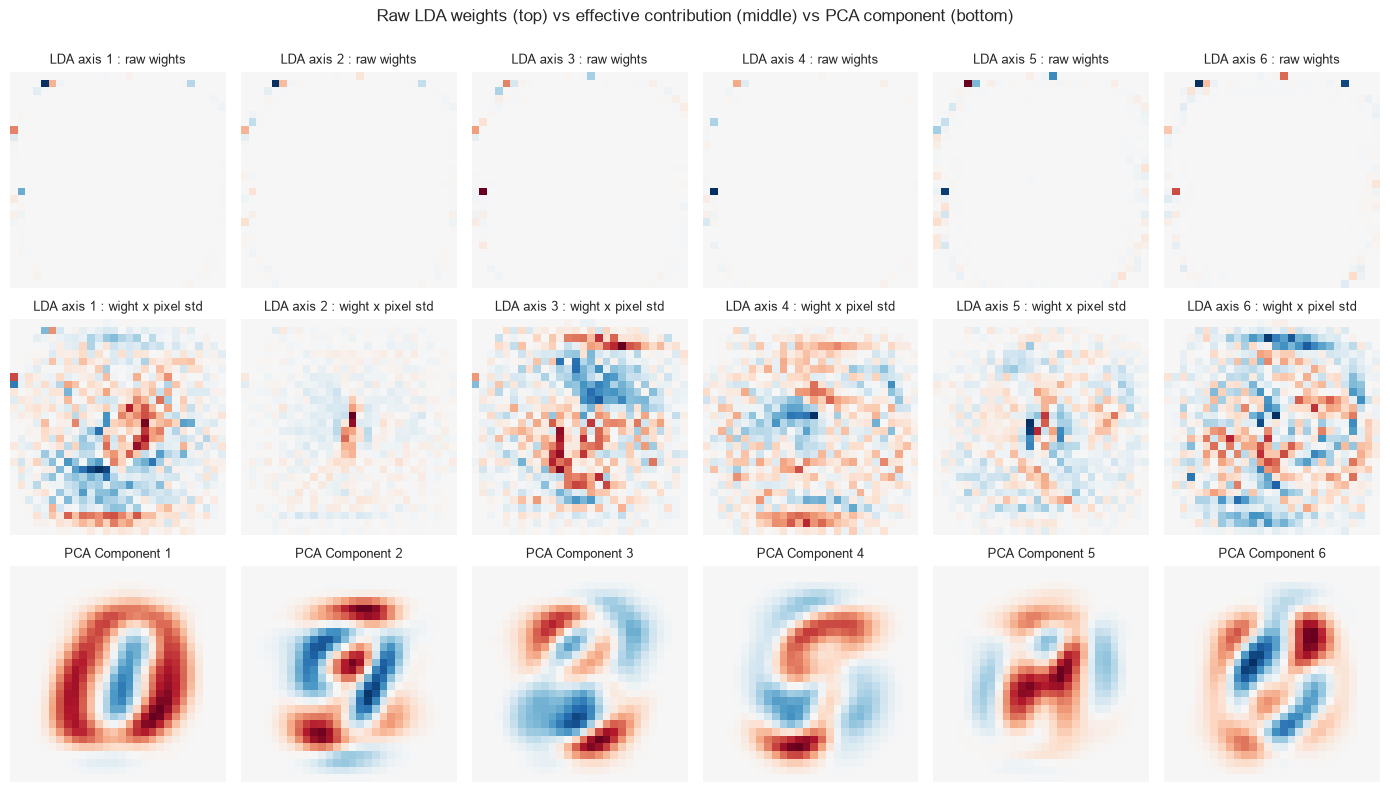

In [84]:
from sklearn.decomposition import PCA
pca9 = PCA(n_components=total_digit-1, random_state=RANDOM_STATE).fit(X_train)
pixel_std = X_train.std(axis=0)

def show(ax, w, title):
    lim = np.abs(w).max()
    ax.imshow(w.reshape(28, 28), cmap='RdBu_r', vmin =-lim, vmax=lim)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

fig, axes = plt.subplots(3, 6, figsize=(14, 8))
for i in range(6):
    show(axes[0,i], lda.scalings_[:,i], f"LDA axis {i+1} : raw wights")
    show(axes[1, i], lda.scalings_[:,i] * pixel_std, f"LDA axis {i+1} : wight x pixel std")
    show(axes[2, i], pca9.components_[i], f"PCA Component {i+1}")

plt.suptitle("Raw LDA weights (top) vs effective contribution (middle) vs PCA component (bottom)", y=1.0)
plt.tight_layout()
plt.show()

**Observation — and a correction to a natural assumption.** The raw
LDA weights (top row) are dominated by a handful of extreme values on
**border pixels**, with almost nothing visible on the digit itself. Read
naively, that says "LDA looks at the corners." It doesn't. Those border
pixels almost never contain ink, so their within-class variance is nearly
zero, and LDA's whitening step divides by that variance, handing them huge
raw weights. Multiplying each weight by the pixel's standard deviation
(middle row) gives each pixel's *effective* contribution: now the border
goes quiet and the signal sits in the central region where ink actually
varies. But it is **speckled and high-frequency**, nothing like PCA's
smooth, stroke-shaped templates (bottom row). That is consistent with LDA
fitting pixel-level class differences, noise included, which is the same
property that shows up as overfitting in Section 10 (consistent with it,
not proven by this figure alone).

**General lesson:** a raw weight is not an importance. Whenever features sit
on different scales or have very different variances, weights must be put on
a common footing (multiply by feature std, or standardize first) before
being read as "what the model cares about." The same caution applies to
linear-regression coefficients and logistic-regression weights.

Section 4b tests whether those near-constant pixels actually *harm* LDA.

### 4b. Do the near-constant pixels hurt? A Variance Threshold test

The filter-methods series had a notebook on Variance Threshold for
exactly this kind of feature. Dropping pixels below a variance cutoff
before LDA tests whether the extreme border weights matter for accuracy.

In [106]:
pix_var = X_train.var(axis=0)
table=[]

threshold = [0.0, 1e-4, 1e-3, 1e-2, 2e-2]

for t in threshold:
    keep = pix_var > t
    lda = LDA().fit(X_train[:, keep], y_train)
    acc_clf = lda.score(X_test[:, keep], y_test)
    acc_knn = knn_benchmark(lda.transform(X_train[:, keep]),lda.transform(X_test[:,keep]), y_train, y_test)

    table.append({"variance threshold":t, "pixels kept": int(keep.sum()),
                "LDA classifier accuracy": acc_clf, "KNN-on-LDA-9 accuracy":acc_knn['accuracy']})

variance_threshold = pd.DataFrame(table)
variance_threshold.round(4)

,variance threshold,pixels kept,LDA classifier accuracy,KNN-on-LDA-9 accuracy
0,0.0000,718,0.8663,0.9136
1,0.0001,621,0.8671,0.9149
2,0.0010,542,0.8665,0.9154
3,0.0100,443,0.8647,0.9124
4,0.0200,395,0.8669,0.9124


**Observation:** accuracy is flat to within a fraction of a point whether
72 or 389 pixels are removed (LDA classifier 86.4-86.7%, KNN-on-LDA 91.5-91.6%).
The extreme border weights are real but **harmless**: those pixels barely
vary, so even large weights contribute almost nothing to the projection.
That makes Variance Threshold a poor lever *for accuracy* here, though it
remains a free way to shrink the input (and avoid the singular-matrix error
from Section 3 when using the `eigen` solver).
